### TO DO

##### include Obs
##### process ERA5 file with CDO or NCKS

In [10]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import griddata
import xesmf as xe
from pathlib import Path
import cartopy.crs as ccrs
import netCDF4  
import time

In [11]:
year_list = ["2003"]#,"2004","2005","2006","2007","2008","2009","2010","2011","2012","2013"]
month_list = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
season_list = ["DJF","MAM","JJA","SON"]

#### Load MAR outputs

In [12]:
# MAR topography
coord = xr.open_dataset('/home/amoryc/NST.2000.01.01.00.GRa_Fedchenko.nc')
lon = coord.LON
lat = coord.LAT
H = coord.SH

In [13]:
# MAR dataset
folder = '/bettik/amoryc/MARout/GRf/spin3/work/'

# Surface temperature
t2m_yr = xr.open_dataset(folder+'year-TT-MARv3.14_ER5-2003-2013.nc')
t2m_mon = xr.open_dataset(folder+'mon-TT-MARv3.14_ER5-2003-2013.nc')

# Rain
wpr_yr = xr.open_dataset(folder+ 'year-RF-MARv3.14_ER5-2003-2013.nc')
wpr_mon = xr.open_dataset(folder+ 'mon-RF-MARv3.14_ER5-2003-2013.nc')

# Snow fall
spr_yr = xr.open_dataset(folder+ 'year-SF-MARv3.14_ER5-2003-2013.nc')
spr_mon = xr.open_dataset(folder+ 'mon-SF-MARv3.14_ER5-2003-2013.nc')

# Snow height
sh_yr = xr.open_dataset(folder+ 'year-SHSN3-MARv3.14_ER5-2003-2013.nc')
sh_mon = xr.open_dataset(folder+ 'mon-SHSN3-MARv3.14_ER5-2003-2013.nc')

### Load Observations

In [14]:
# CRU, APHRODITE SNOW-CCI => Maria a déjà tout sur Spirit

### Load ERA5

In [15]:
# need to create 1 file / yr / variable of interest from ERA5 database

In [16]:
folder_era5 = '/bettik/PROJECTS/pr-regional-climate/inputs/MAR/forcings/Asia/ERA5-HMA/'
folder_out_era5 = '/bettik/fainx/MAR_HMA/forcings/ERA5/'

file_ERA5= 'ECM.*.nc'

In [17]:
#Open and combine all ERA5 dataset
# => better to do it with CDO.. because lack of mem

for i in range(len(year_list)):
    folder_year=year_list[i]
    path_era5_t2m = Path(folder_out_era5 + 'ds_era5_t2m_' + folder_year + '.nc')
        
    if path_era5_t2m.is_file():
        print(f'The file {path_era5_t2m} already exists')
        ds_era5_t2m = xr.open_mfdataset(path_era5_t2m + 'ds_era5_t2m.nc', parallel=True).tas.load()
    else:
        print(f'The file {path_era5_t2m} does not exist')
        print(f'Extracting ERA5 data')
        ds_era5_t2m= xr.open_mfdataset(folder_era5 + folder_year + '/'+ file_ERA5,  combine='by_coords', parallel=True).T #concat_dim ='time',
        # ds_era5_t2m.to_netcdf(folder_out_era5 + 'ds_era5_t2m_' + folder_year + '.nc')

The file /bettik/fainx/MAR_HMA/forcings/ERA5/ds_era5_t2m_2003.nc already exists


TypeError: unsupported operand type(s) for +: 'PosixPath' and 'str'

In [ ]:
ds_era5_t2m.isel(time=10).isel(level=0).plot()

## First Plots

/tmp/ipykernel_356504/2406091145.py:2: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = plt.pcolormesh(coord.LON, coord.LAT, t2m_yr.TT.isel(TIME=0).isel(ATMLAY=0), cmap='RdBu_r')


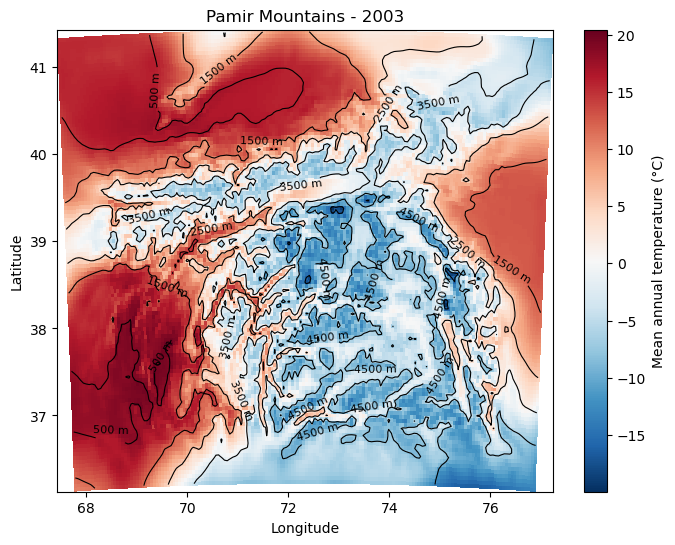

In [18]:
plt.figure(figsize=(8, 6))  
mesh = plt.pcolormesh(coord.LON, coord.LAT, t2m_yr.TT.isel(TIME=0).isel(ATMLAY=0), cmap='RdBu_r')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Pamir Mountains - 2003")

levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m 
contours = plt.contour(coord.LON, coord.LAT, coord.SH, levels=levels, colors='black', linewidths=0.8)

# labels sur les courbes de niveau
plt.clabel(contours, inline=True, fontsize=8, fmt='%d m') 

cbar = plt.colorbar(mesh)
cbar.set_label("Mean annual temperature (°C)")

plt.show()

/tmp/ipykernel_3284283/3931192647.py:6: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(coord.LON, coord.LAT, data.TT.isel(TIME=i).isel(ATMLAY=0), cmap='RdBu_r', shading='auto')
/tmp/ipykernel_3284283/3931192647.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


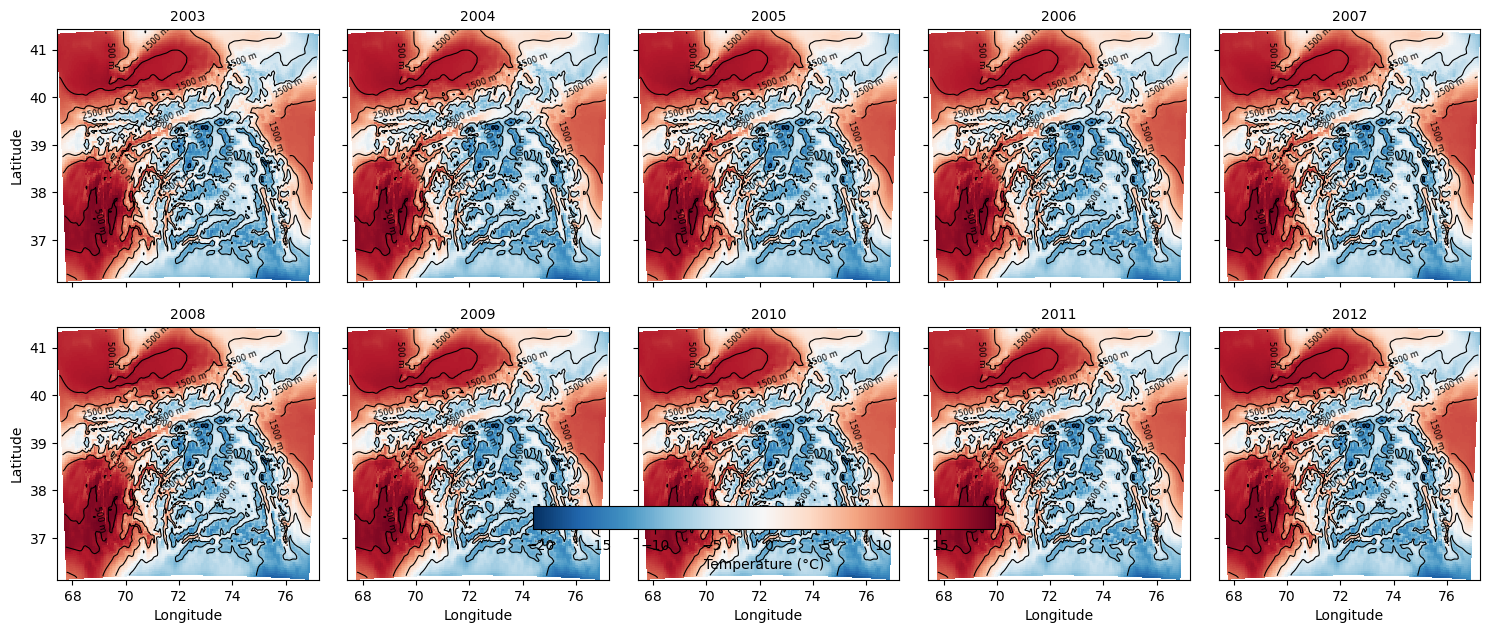

In [18]:
years = np.arange(2003, 2013) 

fig, axes = plt.subplots(2, 5, figsize=(15, 6), sharex=True, sharey=True)

for i, ax in enumerate(axes.flat):
    mesh = ax.pcolormesh(coord.LON, coord.LAT, data.TT.isel(TIME=i).isel(ATMLAY=0), cmap='RdBu_r', shading='auto')
    
    levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m
    contours = ax.contour(coord.LON, coord.LAT, coord.SH, levels=levels, colors='black', linewidths=0.8)
    ax.clabel(contours, inline=True, fontsize=6, fmt='%d m')

    ax.set_title(f"{years[i]}", fontsize=10)

    # Axes (seulement pour les bords)
    if i % 5 == 0:
        ax.set_ylabel("Latitude")
    if i >= 5:
        ax.set_xlabel("Longitude")


cbar = fig.colorbar(mesh, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1)
cbar.set_label("Temperature (°C)")

# Ajustement des espacements
plt.tight_layout()

plt.show()

# Seasonnal variability

## Surface Temperature

#### Add comparison with CRU, ERA5, including differences (MAR-CRU..)

/tmp/ipykernel_356504/2447914921.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(coord.LON, coord.LAT,t2m_mon.TT.isel(ATMLAY=0).groupby("TIME.season").mean('TIME').sel(season=season_list[i]), cmap='RdBu_r', shading='auto',  vmin=-20, vmax=20)
/tmp/ipykernel_356504/2447914921.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(coord.LON, coord.LAT,t2m_mon.TT.isel(ATMLAY=0).groupby("TIME.season").mean('TIME').sel(season=season_list[i]), cmap='RdBu_r', shading='auto',  vmin=-20, vmax=20)
/tmp/ipykernel_356504/2447914921.py:7: UserWarning: 

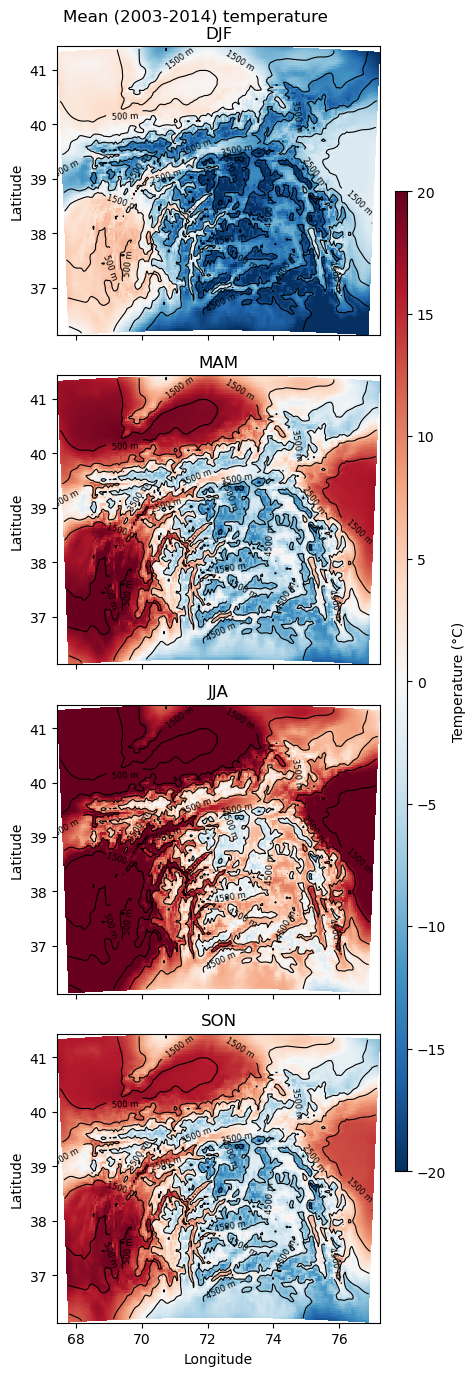

In [92]:
nrows=4
ncols=1

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(4, 14)) 

for i, ax in enumerate(axes.flat):
    mesh = ax.pcolormesh(coord.LON, coord.LAT,t2m_mon.TT.isel(ATMLAY=0).groupby("TIME.season").mean('TIME').sel(season=season_list[i]), cmap='RdBu_r', shading='auto',  vmin=-20, vmax=20)
    
    levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m
    contours = ax.contour(coord.LON, coord.LAT, coord.SH, levels=levels, colors='black', linewidths=0.8)
    ax.clabel(contours, inline=True, fontsize=6, fmt='%d m')
    
    ax.set_title(season_list[i]) 
    ax.set_ylabel('Latitude') 
    # if i % 5 == 0:
    #     axs[i].set_ylabel("Latitude")
    if i >= 3:
        ax.set_xlabel("Longitude")

fig.suptitle('Mean (2003-2014) temperature', fontsize=12)

cbar_ax = fig.add_axes([1, 0.15, 0.03, 0.7]) 
fig.colorbar(mesh, cax=cbar_ax, orientation='vertical', label='Temperature (°C)')

plt.tight_layout()
plt.show()

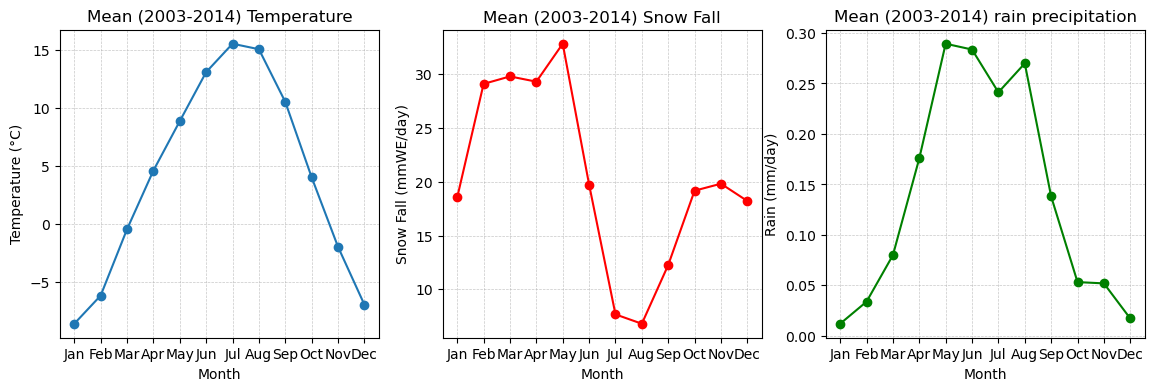

In [90]:
#Ajouter une dépendance à l'altitude

nrows=1
ncols=3

fig, ax = plt.subplots(nrows=nrows, ncols=ncols,  figsize=(14, 4)) 

ax[0].plot(t2m_mon.TT.isel(ATMLAY=0).groupby('TIME.month').mean('TIME').mean(('X', 'Y')),marker='o', linestyle='-')

ax[0].set_xticks(np.arange(0, 12))
ax[0].set_xticklabels(month_list)

ax[0].set_xlabel("Month")
ax[0].set_ylabel("Temperature (°C)")
ax[0].set_title("Mean (2003-2014) Temperature")
ax[0].grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

ax[1].plot(spr_mon.SF.groupby('TIME.month').mean('TIME').mean(('X', 'Y')),marker='o', linestyle='-', color = 'r')

ax[1].set_xticks(np.arange(0, 12))
ax[1].set_xticklabels(month_list)

ax[1].set_xlabel("Month")
ax[1].set_ylabel("Snow Fall (mmWE/day)")
ax[1].set_title("Mean (2003-2014) Snow Fall")
ax[1].grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

ax[2].plot(wpr_mon.RF.groupby('TIME.month').mean('TIME').mean(('X', 'Y')),marker='o', linestyle='-', color = 'g')

ax[2].set_xticks(np.arange(0, 12))
ax[2].set_xticklabels(month_list)

ax[2].set_xlabel("Month")
ax[2].set_ylabel("Rain (mm/day)")
ax[2].set_title("Mean (2003-2014) rain precipitation")
ax[2].grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

plt.show()

## Snow Pack Characteristics

##### Need to include comparison with SNOW-CCI

/tmp/ipykernel_356504/1796893423.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(coord.LON, coord.LAT,sh_mon.SHSN3.groupby("TIME.season").mean('TIME').isel(SECTOR=1).sel(season=season_list[i]), shading='auto',  vmin=0, vmax=8)
/tmp/ipykernel_356504/1796893423.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(coord.LON, coord.LAT,sh_mon.SHSN3.groupby("TIME.season").mean('TIME').isel(SECTOR=1).sel(season=season_list[i]), shading='auto',  vmin=0, vmax=8)
/tmp/ipykernel_356504/1796893423.py:7: UserWarning: The input coordinates to pcolorm

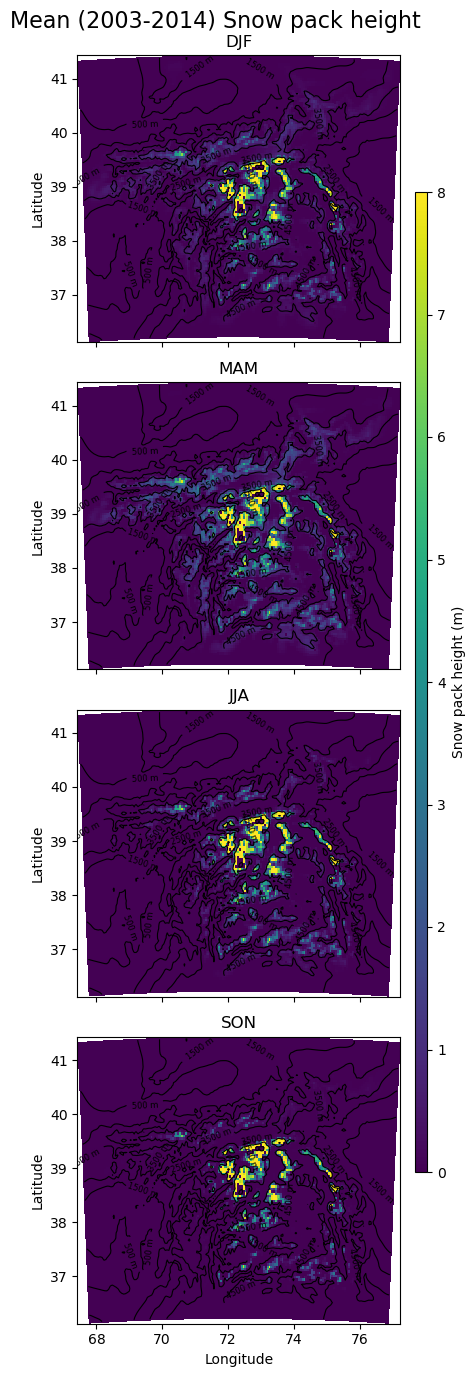

In [46]:
nrows=4
ncols=1

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(4, 14)) 

for i, ax in enumerate(axes.flat):
    mesh = ax.pcolormesh(coord.LON, coord.LAT,sh_mon.SHSN3.groupby("TIME.season").mean('TIME').isel(SECTOR=1).sel(season=season_list[i]), shading='auto',  vmin=0, vmax=8)
    
    levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m
    contours = ax.contour(coord.LON, coord.LAT, coord.SH, levels=levels, colors='black', linewidths=0.8)
    ax.clabel(contours, inline=True, fontsize=6, fmt='%d m')
    
    ax.set_title(season_list[i]) 
    ax.set_ylabel('Latitude') 
    # if i % 5 == 0:
    #     axs[i].set_ylabel("Latitude")
    if i >= 3:
        ax.set_xlabel("Longitude")

fig.suptitle('Mean (2003-2014) Snow pack height', fontsize=16)

cbar_ax = fig.add_axes([1, 0.15, 0.03, 0.7]) 
fig.colorbar(mesh, cax=cbar_ax, orientation='vertical', label='Snow pack height (m)')

plt.tight_layout()
plt.show()